In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

## 1. Load Data

In [2]:
df = pd.read_csv('qtl.csv')
df.head(10)

,noise_type,noise_strength,accuracy_no_zne,precision_no_zne,sensitivity_no_zne,f1_no_zne,specificity_no_zne,roc_auc_no_zne,accuracy_zne,precision_zne,sensitivity_zne,f1_zne,specificity_zne,roc_auc_zne,zne_gain,recall_no_zne,recall_zne
0,pauli,0.02,0.884956,0.938835,0.890424,0.913989,0.872984,0.942425,0.895702,0.938154,0.907919,0.922789,0.868952,0.946717,0.010746,0.890424,0.907919
1,pauli,0.15,0.782554,0.920635,0.747698,0.825203,0.858871,0.865887,0.866625,0.942366,0.858195,0.898313,0.885081,0.939912,0.084071,0.747698,0.858195
2,pauli,0.25,0.640329,0.785006,0.655617,0.714501,0.606855,0.671527,0.818584,0.936612,0.789134,0.856572,0.883065,0.904776,0.178255,0.655617,0.789134
3,phase,0.02,0.895070,0.937262,0.907919,0.922357,0.866935,0.943935,0.897598,0.940000,0.908840,0.924157,0.872984,0.947349,0.002528,0.907919,0.908840
4,phase,0.15,0.870417,0.946302,0.860037,0.901110,0.893145,0.938250,0.893805,0.939655,0.903315,0.921127,0.872984,0.945763,0.023388,0.860037,0.903315
5,phase,0.25,0.852718,0.957128,0.822284,0.884596,0.919355,0.926135,0.888116,0.942551,0.891344,0.916233,0.881048,0.944620,0.035398,0.822284,0.891344
6,depolarizing,0.02,0.884956,0.937984,0.891344,0.914070,0.870968,0.942293,0.895702,0.938154,0.907919,0.922789,0.868952,0.946812,0.010746,0.891344,0.907919
7,depolarizing,0.15,0.778761,0.915350,0.746777,0.822515,0.848790,0.853697,0.863464,0.941176,0.854512,0.895753,0.883065,0.939817,0.084703,0.746777,0.854512
8,depolarizing,0.25,0.612516,0.757906,0.639963,0.693959,0.552419,0.628741,0.810999,0.930997,0.782689,0.850425,0.872984,0.899498,0.198483,0.639963,0.782689


## 2. Baseline Accuracy per Noise Type

Since there is no explicit `noise_strength = 0` row, the **minimum noise strength** row for each noise type is used as the clean reference $\text{Acc}(0)$.

In [3]:
# Reference: lowest noise_strength per noise_type
baseline = (
    df.sort_values('noise_strength')
      .groupby('noise_type')
      .first()[['noise_strength', 'accuracy_no_zne']]
      .rename(columns={
          'noise_strength': 'ref_strength',
          'accuracy_no_zne': 'acc_ref'
      })
)

print("Reference (clean proxy) per noise type:")
print(baseline.to_string())

Reference (clean proxy) per noise type:
              ref_strength   acc_ref
noise_type                          
depolarizing          0.02  0.884956
pauli                 0.02  0.884956
phase                 0.02  0.895070


## 3. Compute Noise Sensitivity Index (NSI)

$$S_p = \frac{\text{Acc}(0) - \text{Acc}(p)}{p}$$

Computed for every row **excluding** the reference row itself (to avoid division by near-zero differences).

In [4]:
df = df.merge(baseline, on='noise_type')

# NSI — no_zne branch (primary)
df['NSI_no_zne'] = (df['acc_ref'] - df['accuracy_no_zne']) / df['noise_strength']

# NSI — zne branch (for comparison)
df['NSI_zne'] = (df['acc_ref'] - df['accuracy_zne']) / df['noise_strength']

# Mark reference rows (lowest strength per type)
df['is_ref'] = df['noise_strength'] == df['ref_strength']

nsi_cols = ['noise_type', 'noise_strength', 'accuracy_no_zne', 'accuracy_zne',
            'NSI_no_zne', 'NSI_zne', 'is_ref']
print(df[nsi_cols].to_string(index=False))

  noise_type  noise_strength  accuracy_no_zne  accuracy_zne  NSI_no_zne   NSI_zne  is_ref
       pauli            0.02         0.884956      0.895702    0.000000 -0.537295    True
       pauli            0.15         0.782554      0.866625    0.682680  0.122208   False
       pauli            0.25         0.640329      0.818584    0.978508  0.265487   False
       phase            0.02         0.895070      0.897598    0.000000 -0.126422    True
       phase            0.15         0.870417      0.893805    0.164349  0.008428   False
       phase            0.25         0.852718      0.888116    0.169406  0.027813   False
depolarizing            0.02         0.884956      0.895702    0.000000 -0.537295    True
depolarizing            0.15         0.778761      0.863464    0.707965  0.143279   False
depolarizing            0.25         0.612516      0.810999    1.089760  0.295828   False


## 4. Compute ZNE Efficiency Score

$$E_{\text{ZNE}} = \frac{\text{Acc}_{\text{ZNE}} - \text{Acc}_{\text{noZNE}}}{\text{extra circuit evaluations}}$$

ZNE with Richardson extrapolation over 3 noise scale factors (1×, 2×, 3×) requires **2 extra circuit evaluations** per inference call.

In [5]:
EXTRA_EVALS = 2  # adjust if using more scale factors

df['ZNE_efficiency'] = df['zne_gain'] / EXTRA_EVALS

eff_cols = ['noise_type', 'noise_strength', 'zne_gain', 'ZNE_efficiency']
print(df[eff_cols].to_string(index=False))

  noise_type  noise_strength  zne_gain  ZNE_efficiency
       pauli            0.02  0.010746        0.005373
       pauli            0.15  0.084071        0.042035
       pauli            0.25  0.178255        0.089128
       phase            0.02  0.002528        0.001264
       phase            0.15  0.023388        0.011694
       phase            0.25  0.035398        0.017699
depolarizing            0.02  0.010746        0.005373
depolarizing            0.15  0.084703        0.042351
depolarizing            0.25  0.198483        0.099241


## 5. Summary Table

In [6]:
summary = df[[
    'noise_type', 'noise_strength',
    'accuracy_no_zne', 'accuracy_zne',
    'NSI_no_zne', 'NSI_zne',
    'zne_gain', 'ZNE_efficiency'
]].copy()

for col in ['accuracy_no_zne', 'accuracy_zne', 'NSI_no_zne',
            'NSI_zne', 'zne_gain', 'ZNE_efficiency']:
    summary[col] = summary[col].round(5)

summary = summary.rename(columns={
    'noise_type':       'Noise Type',
    'noise_strength':   'p',
    'accuracy_no_zne':  'Acc (no ZNE)',
    'accuracy_zne':     'Acc (ZNE)',
    'NSI_no_zne':       'NSI (no ZNE)',
    'NSI_zne':          'NSI (ZNE)',
    'zne_gain':         'ZNE Gain',
    'ZNE_efficiency':   'ZNE Efficiency'
})

summary

,Noise Type,p,Acc (no ZNE),Acc (ZNE),NSI (no ZNE),NSI (ZNE),ZNE Gain,ZNE Efficiency
0,pauli,0.02,0.88496,0.89570,0.00000,-0.53729,0.01075,0.00537
1,pauli,0.15,0.78255,0.86662,0.68268,0.12221,0.08407,0.04204
2,pauli,0.25,0.64033,0.81858,0.97851,0.26549,0.17826,0.08913
3,phase,0.02,0.89507,0.89760,0.00000,-0.12642,0.00253,0.00126
4,phase,0.15,0.87042,0.89381,0.16435,0.00843,0.02339,0.01169
5,phase,0.25,0.85272,0.88812,0.16941,0.02781,0.03540,0.01770
6,depolarizing,0.02,0.88496,0.89570,0.00000,-0.53729,0.01075,0.00537
7,depolarizing,0.15,0.77876,0.86346,0.70796,0.14328,0.08470,0.04235
8,depolarizing,0.25,0.61252,0.81100,1.08976,0.29583,0.19848,0.09924


## 6. Visualisations

### 6a. NSI vs Noise Strength (no-ZNE & ZNE) per noise type

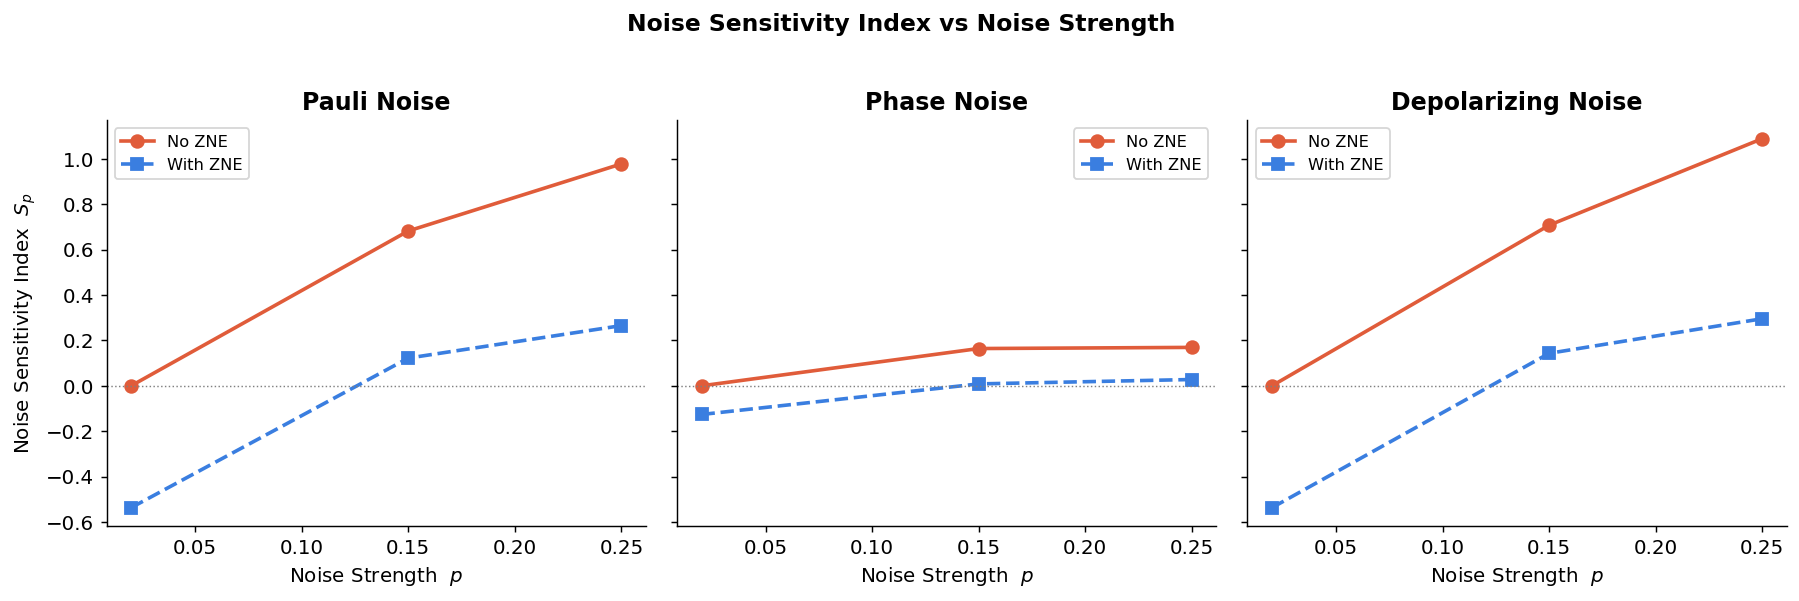

In [7]:
noise_types = df['noise_type'].unique()
colors = {'no_zne': '#E05C3A', 'zne': '#3A7EE0'}
markers = {'no_zne': 'o', 'zne': 's'}

fig, axes = plt.subplots(1, len(noise_types), figsize=(14, 4.5), sharey=True)

for ax, nt in zip(axes, noise_types):
    sub = df[df['noise_type'] == nt].sort_values('noise_strength')
    ax.plot(sub['noise_strength'], sub['NSI_no_zne'],
            color=colors['no_zne'], marker=markers['no_zne'],
            linewidth=2, markersize=7, label='No ZNE')
    ax.plot(sub['noise_strength'], sub['NSI_zne'],
            color=colors['zne'], marker=markers['zne'],
            linewidth=2, markersize=7, linestyle='--', label='With ZNE')
    ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
    ax.set_title(f'{nt.capitalize()} Noise', fontweight='bold')
    ax.set_xlabel('Noise Strength  $p$')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.legend(fontsize=9)

axes[0].set_ylabel('Noise Sensitivity Index  $S_p$')
fig.suptitle('Noise Sensitivity Index vs Noise Strength', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nsi_per_noise_type.png', bbox_inches='tight')
plt.show()

### 6b. ZNE Efficiency Score across all conditions

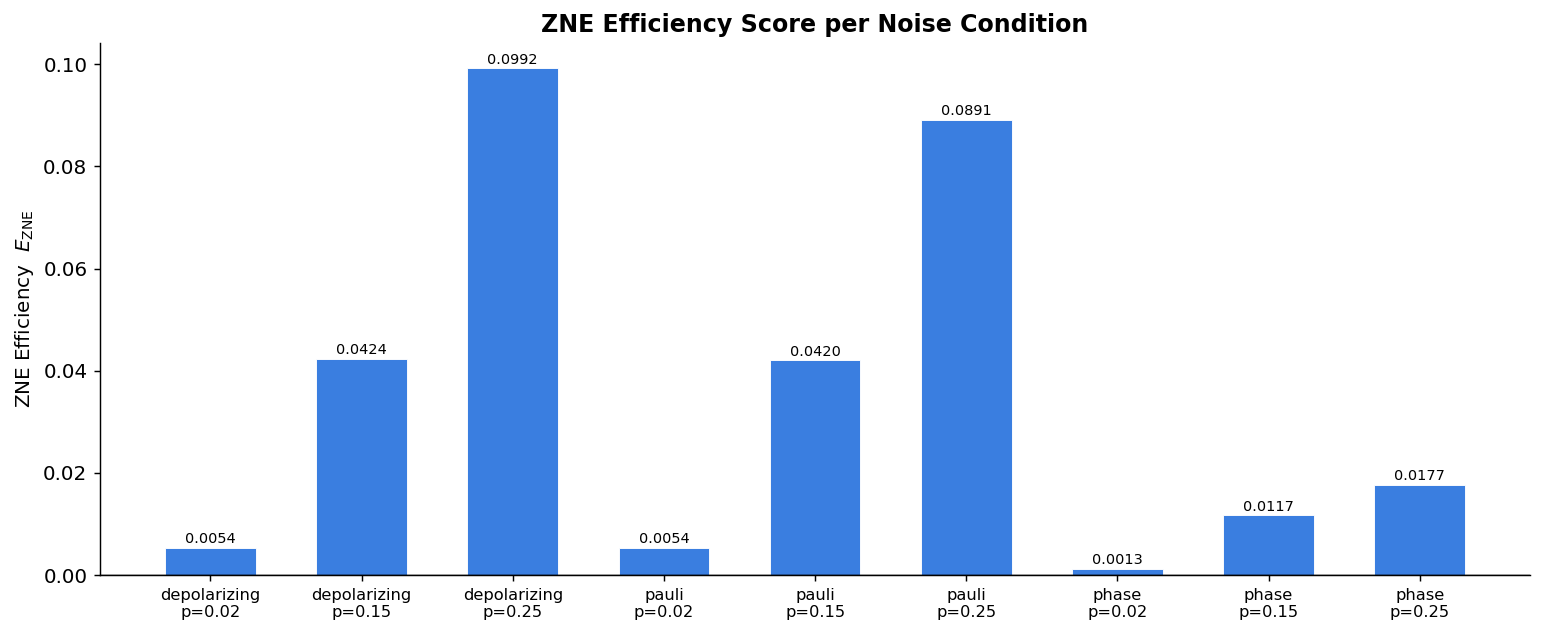

In [ ]:
df_sorted = df.sort_values(['noise_type', 'noise_strength'])
labels = [f"{row['noise_type']}\np={row['noise_strength']}"
          for _, row in df_sorted.iterrows()]

bar_colors = [
    '#3A7EE0' if v >= 0 else '#E05C3A'
    for v in df_sorted['ZNE_efficiency']
]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(labels)), df_sorted['ZNE_efficiency'],
              color=bar_colors, edgecolor='white', linewidth=0.5, width=0.6)

for bar, val in zip(bars, df_sorted['ZNE_efficiency']):
    ypos = bar.get_height() + 0.0003 if val >= 0 else bar.get_height() - 0.001
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f'{val:.4f}', ha='center', va='bottom', fontsize=8)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('ZNE Efficiency  $E_{\\mathrm{ZNE}}$')
plt.tight_layout()
plt.savefig('zne_efficiency.png', bbox_inches='tight')
plt.show()

### 6c. Heatmap — NSI (no-ZNE) across noise types and strengths

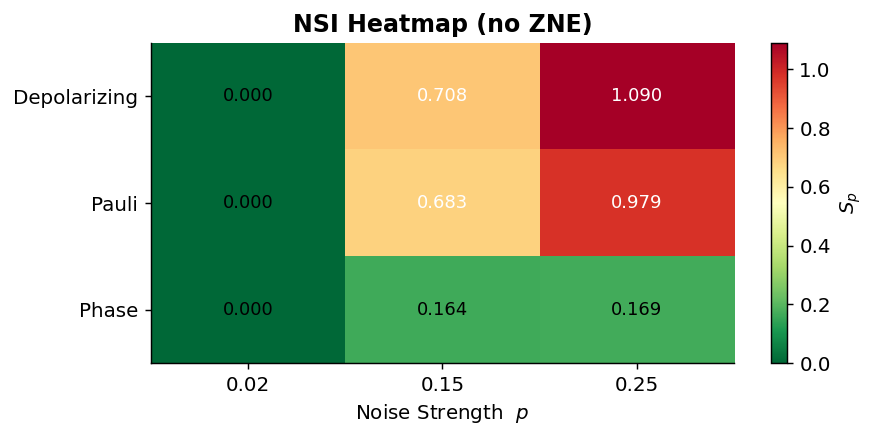

In [9]:
pivot = df.pivot(index='noise_type', columns='noise_strength', values='NSI_no_zne')

fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{c:.2f}' for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([s.capitalize() for s in pivot.index])
ax.set_xlabel('Noise Strength  $p$')
ax.set_title('NSI Heatmap (no ZNE)', fontweight='bold')

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=10,
                color='white' if abs(val) > 0.5 else 'black')

plt.colorbar(im, ax=ax, label='$S_p$')
plt.tight_layout()
plt.savefig('nsi_heatmap.png', bbox_inches='tight')
plt.show()

### 6d. ZNE Efficiency Score — Line Plot per Noise Type (300 dpi)

Saved: zne_efficiency_lineplot.png  (300 dpi)


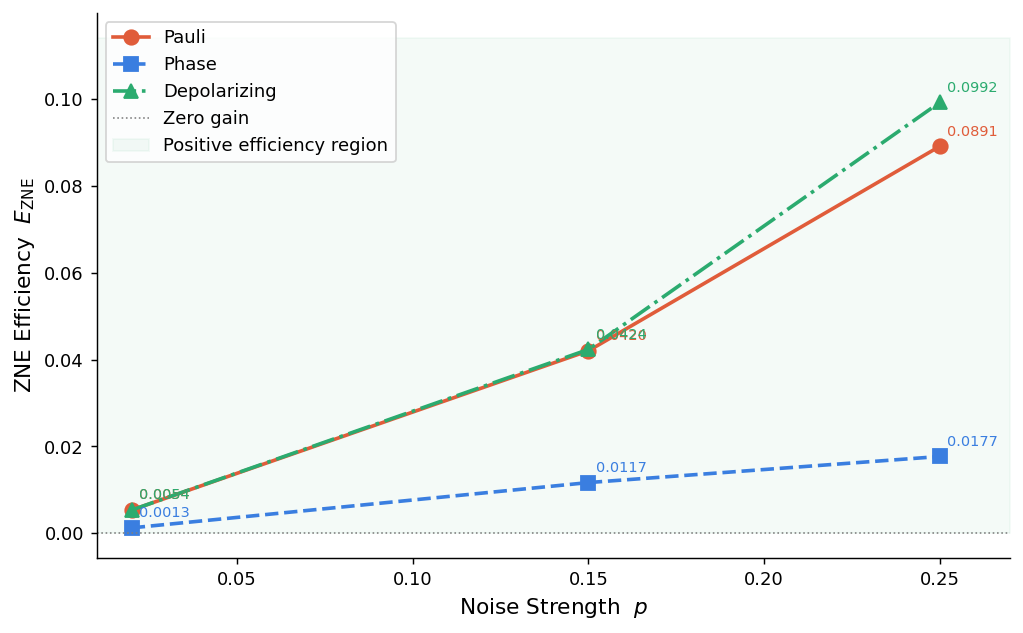

In [10]:
noise_palette = {
    'pauli':       {'color': '#E05C3A', 'marker': 'o', 'ls': '-'},
    'phase':       {'color': '#3A7EE0', 'marker': 's', 'ls': '--'},
    'depolarizing':{'color': '#2BAB6F', 'marker': '^', 'ls': '-.'},
}

fig, ax = plt.subplots(figsize=(8, 5))

for nt, style in noise_palette.items():
    sub = df[df['noise_type'] == nt].sort_values('noise_strength')
    ax.plot(
        sub['noise_strength'],
        sub['ZNE_efficiency'],
        color=style['color'],
        marker=style['marker'],
        linestyle=style['ls'],
        linewidth=2,
        markersize=8,
        label=nt.capitalize()
    )
    # Annotate each point with its value
    for _, row in sub.iterrows():
        ax.annotate(
            f"{row['ZNE_efficiency']:.4f}",
            xy=(row['noise_strength'], row['ZNE_efficiency']),
            xytext=(4, 6),
            textcoords='offset points',
            fontsize=8,
            color=style['color']
        )

ax.axhline(0, color='grey', linewidth=0.9, linestyle=':', label='Zero gain')

# Shaded region: positive efficiency zone
ymin, ymax = ax.get_ylim()
ax.fill_between([0.01, 0.27], 0, max(df['ZNE_efficiency']) * 1.15,
                color='#2BAB6F', alpha=0.05, label='Positive efficiency region')

ax.set_xlabel('Noise Strength  $p$', fontsize=12)
ax.set_ylabel('ZNE Efficiency  $E_{\\mathrm{ZNE}}$', fontsize=12)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(0.01, 0.27)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig('zne_efficiency_lineplot.png', dpi=300, bbox_inches='tight')
print("Saved: zne_efficiency_lineplot.png  (300 dpi)")
plt.show()

## 7. Export Results

In [11]:
out_cols = [
    'noise_type', 'noise_strength',
    'accuracy_no_zne', 'accuracy_zne',
    'NSI_no_zne', 'NSI_zne',
    'zne_gain', 'ZNE_efficiency'
]
df[out_cols].round(6).to_csv('nsi_zne_results.csv', index=False)
print("Results saved to nsi_zne_results.csv")

Results saved to nsi_zne_results.csv
